# 02 · 메쉬 & 기동 시각화

시뮬레이션 전에 형상이 맞는지 확인합니다: **메쉬 로드 모양 → 블레이드 회전 → 기체 자세 회전 → 실제 PX4 궤적**.
모두 `po_sim.mesh` + `po_sim.kinematics` 모듈로 그립니다.


In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# make the package importable whether run from examples/ or po_mdoppler/
cwd = os.getcwd()
PKG = cwd if os.path.isdir(os.path.join(cwd, "po_sim")) else os.path.dirname(cwd)
if PKG not in sys.path:
    sys.path.insert(0, PKG)
print("package root:", PKG)
from configs.default import SimConfig, MESH_DIR, DATA_BASE, BLADE_OFFSETS, BLADE_DIRS
from po_sim import mesh, kinematics
from scipy.spatial.transform import Rotation as Rot

cfg = SimConfig()
dm = mesh.DroneMesh.load(MESH_DIR)
BCOL = ["red", "blue", "green", "orange"]   # per-blade colour

def add_body(ax, R, p, step=2, alpha=0.2):
    bw = dm.body_vertices_world(R, p)
    ax.add_collection3d(Poly3DCollection(bw[dm.body_f[::step]], alpha=alpha,
        facecolor="gray", edgecolor="gray", linewidth=0.05))

def add_blades(ax, R, p, angles, alpha=0.6):
    """angles = unsigned per-blade angle; spin sign from BLADE_DIRS (as in the sim)."""
    for b in range(dm.n_blades):
        a = angles[b] * BLADE_DIRS[b]
        vw = dm.blade_vertices_world(b, a, R, p, BLADE_OFFSETS[b])
        ax.add_collection3d(Poly3DCollection(vw[dm.blade_f_list[b]], alpha=alpha,
            facecolor=BCOL[b], edgecolor=BCOL[b], linewidth=0.1))

print("helpers ready | total tris:", dm.total_tris)

package root: /workspace/sionna_sim/po_mdoppler


helpers ready | total tris: 31446


## 1) 메쉬 로드 모양
body(회색) + 4 blade(색). Mesh/ = 삼각화 + 법선 외향 보정본.

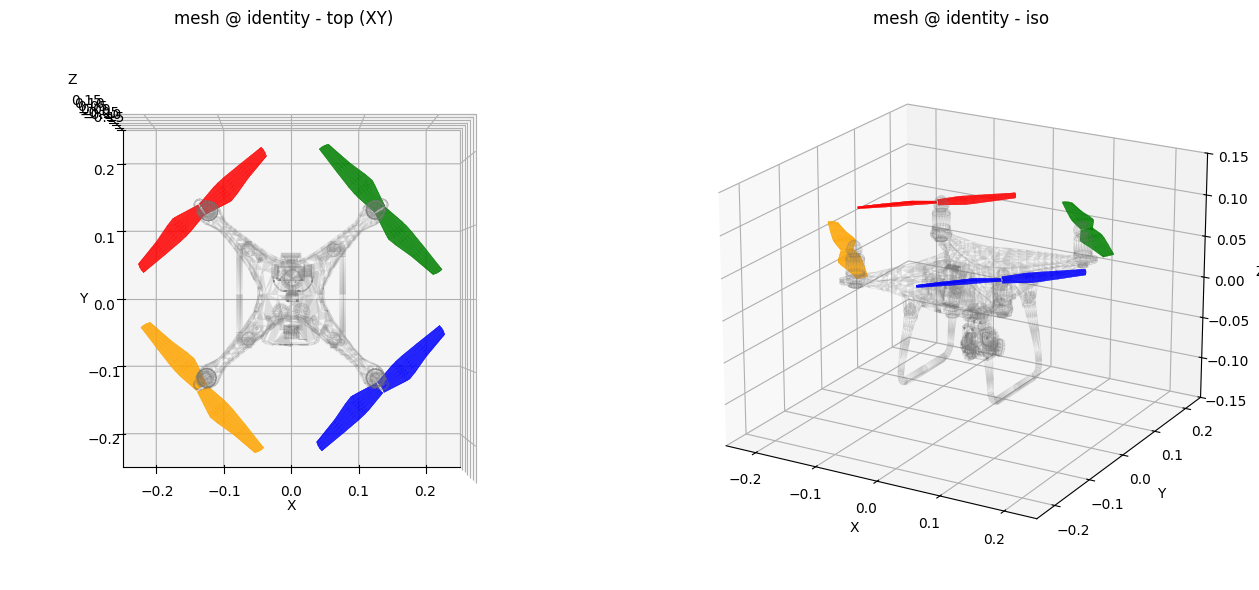

In [2]:
fig = plt.figure(figsize=(14, 6))
for i, (elev, azim, ttl) in enumerate([(90, -90, "top (XY)"), (20, -60, "iso")]):
    ax = fig.add_subplot(1, 2, i+1, projection="3d")
    add_body(ax, np.eye(3), np.zeros(3)); add_blades(ax, np.eye(3), np.zeros(3), np.zeros(4))
    lim = 0.25; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-0.15, 0.15)
    ax.set_title("mesh @ identity - " + ttl); ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.tight_layout(); plt.show()

## 2) 블레이드 회전 스냅샷 (0/90/180/270°)
`blade_dirs = [-1,-1,+1,+1]` → 앞 2개 CCW, 뒤 2개 CW.

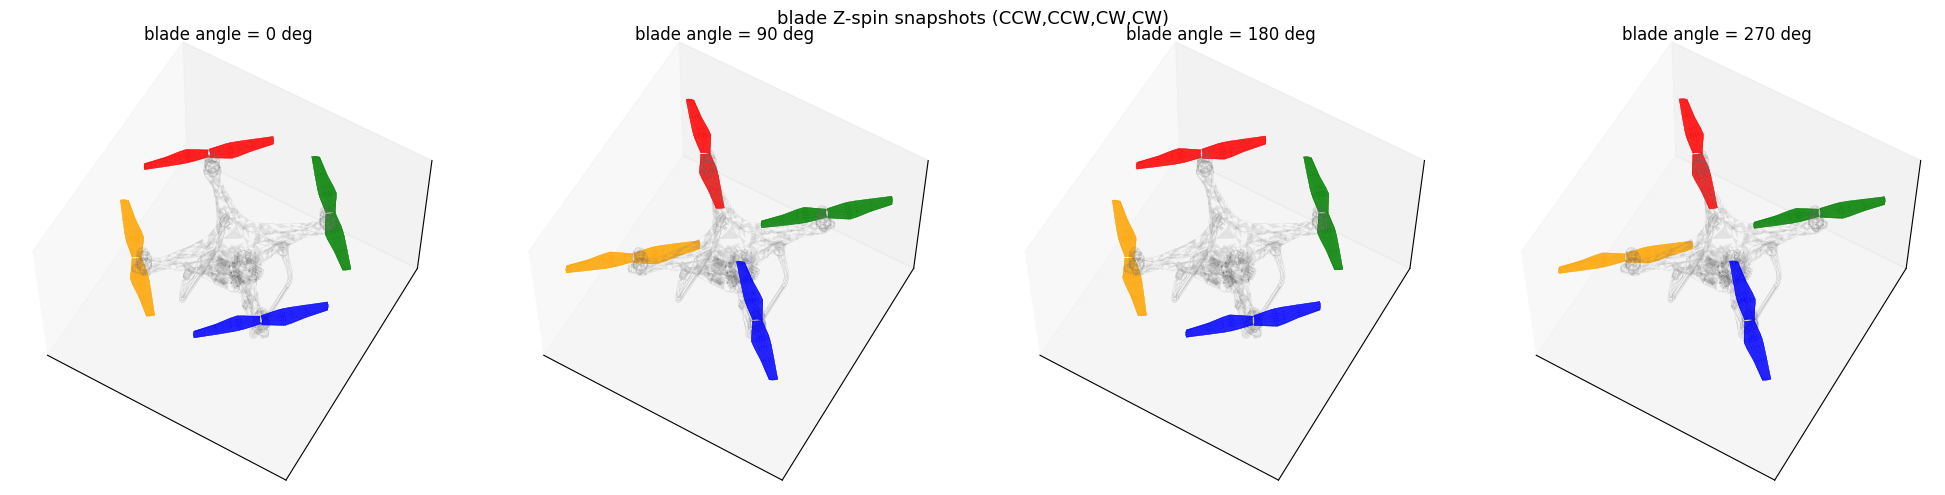

In [3]:
fig = plt.figure(figsize=(20, 5))
for i, deg in enumerate([0, 90, 180, 270]):
    ax = fig.add_subplot(1, 4, i+1, projection="3d")
    add_body(ax, np.eye(3), np.zeros(3), step=3, alpha=0.15)
    add_blades(ax, np.eye(3), np.zeros(3), np.full(4, np.deg2rad(deg)))
    lim = 0.25; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-0.15, 0.15)
    ax.set_title("blade angle = %d deg" % deg); ax.view_init(elev=60, azim=-60)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.suptitle("blade Z-spin snapshots (CCW,CCW,CW,CW)", fontsize=13); plt.tight_layout(); plt.show()

## 3) 실제 ESC RPM 기반 블레이드 회전 (~1 회전)
`kinematics` 의 누적각(∫RPM·dt ×rpm_scale) 을 그대로 사용.

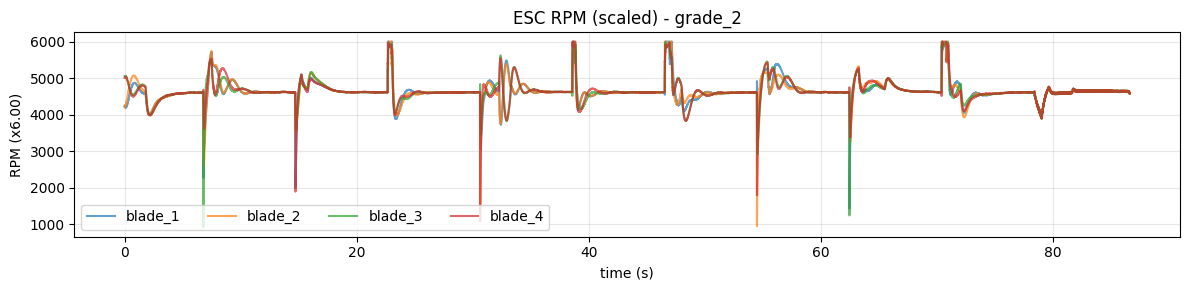

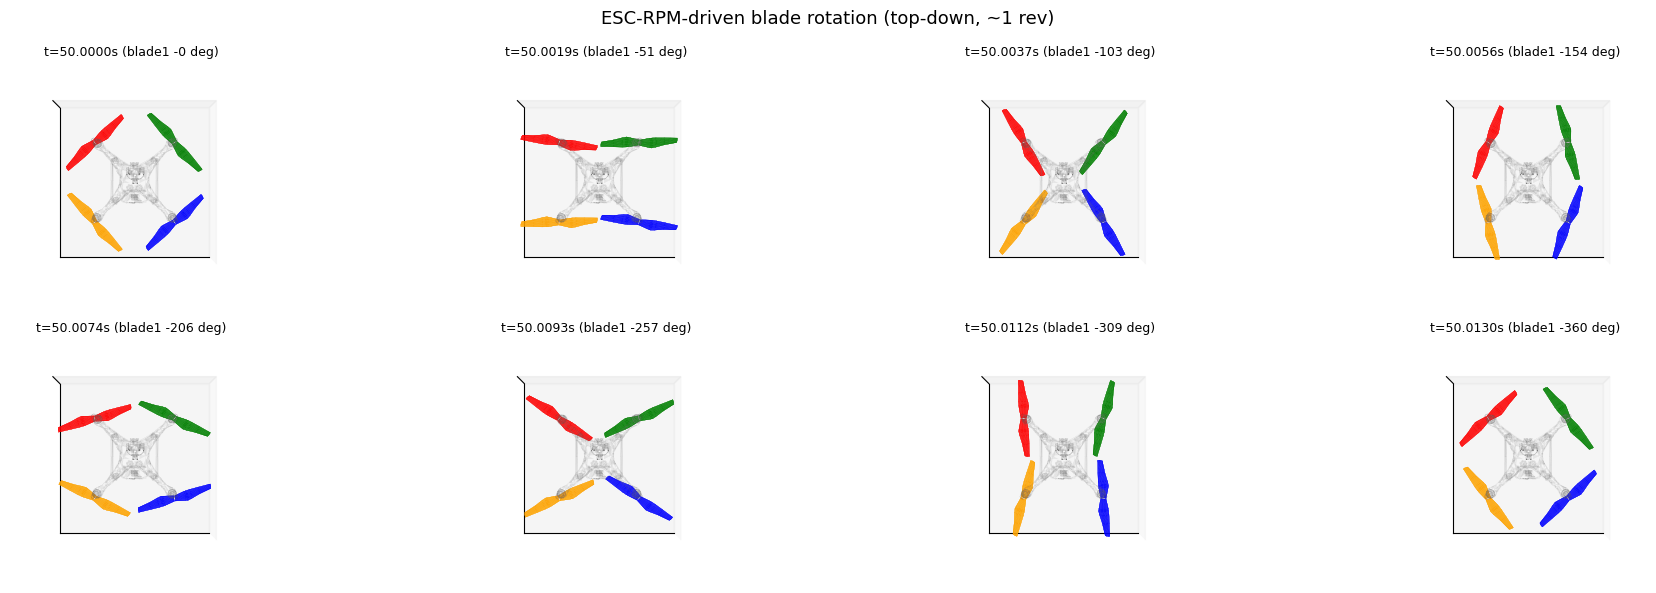

In [4]:
flight = kinematics.load_flight(os.path.join(DATA_BASE, "grade_2"), cfg)

# RPM time series (scaled) for context
import pandas as pd
esc = pd.read_csv(os.path.join(DATA_BASE, "grade_2", "clean_esc.csv"))
cols = ["esc[0].esc_rpm", "esc[1].esc_rpm", "esc[2].esc_rpm", "esc[3].esc_rpm"]
fig, ax = plt.subplots(figsize=(12, 3))
for i, c in enumerate(cols):
    ax.plot(esc["time_sec"], esc[c]*cfg.rpm_scale, label="blade_%d" % (i+1), alpha=0.7)
ax.set_xlabel("time (s)"); ax.set_ylabel("RPM (x%.2f)" % cfg.rpm_scale)
ax.set_title("ESC RPM (scaled) - grade_2"); ax.legend(ncol=4); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ~1 revolution span from the actual angular rate
t0 = 50.0
rate = (flight.blade_angles_interp(t0 + 1e-4)[0] - flight.blade_angles_interp(t0)[0]) / 1e-4
span = 2*np.pi / max(rate, 1e-6)
ts = np.linspace(t0, t0 + span, 8)
ang = flight.blade_angles_interp(ts); ang0 = ang - ang[0]
fig = plt.figure(figsize=(20, 6))
for i, t in enumerate(ts):
    ax = fig.add_subplot(2, 4, i+1, projection="3d")
    add_body(ax, np.eye(3), np.zeros(3), step=3, alpha=0.12)
    add_blades(ax, np.eye(3), np.zeros(3), ang0[i])
    lim = 0.25; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-0.1, 0.1)
    ax.set_title("t=%.4fs (blade1 %+.0f deg)" % (t, np.rad2deg(ang0[i, 0]*BLADE_DIRS[0])), fontsize=9)
    ax.view_init(elev=90, azim=-90); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.suptitle("ESC-RPM-driven blade rotation (top-down, ~1 rev)", fontsize=13); plt.tight_layout(); plt.show()

## 4) 기체 자세 회전 (roll / pitch / yaw)
`R_body` 를 body 와 blade 에 함께 적용(블레이드는 spin 후 R_body).

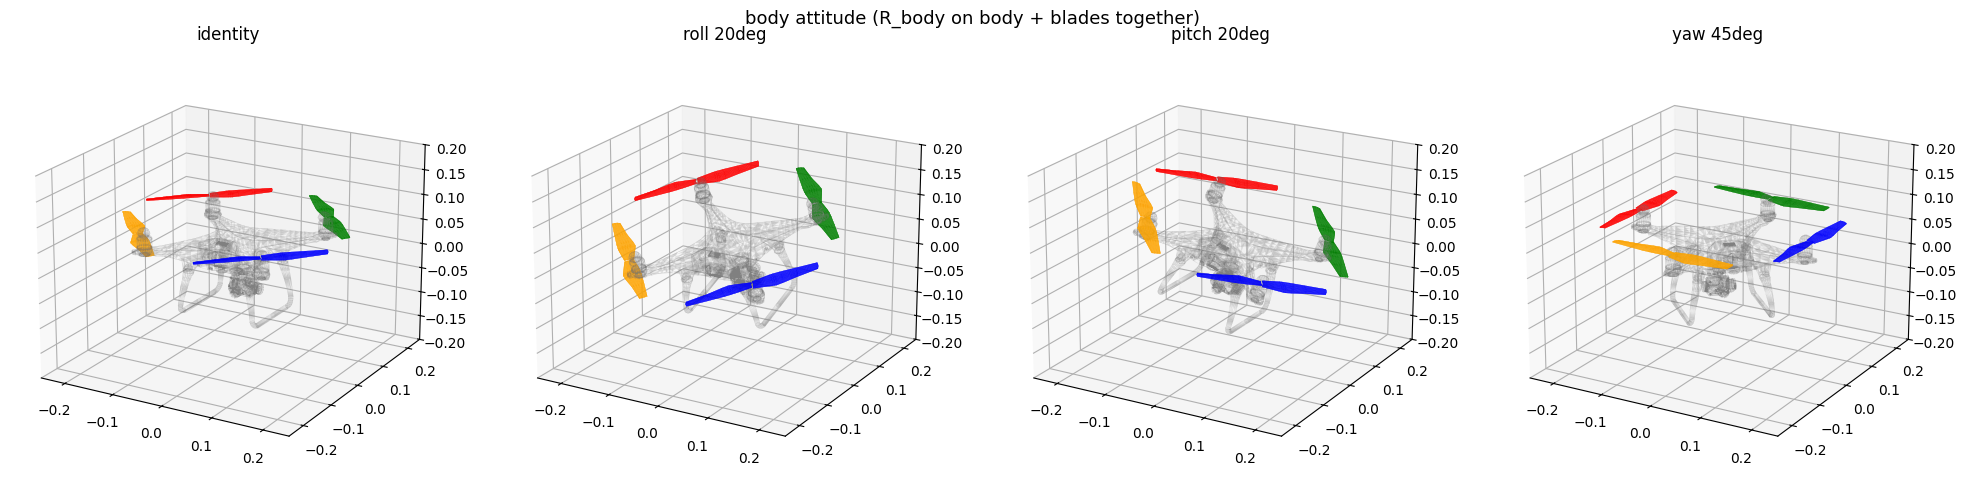

In [5]:
poses = [("identity", [0, 0, 0]), ("roll 20deg", [20, 0, 0]),
         ("pitch 20deg", [0, 20, 0]), ("yaw 45deg", [0, 0, 45])]
fig = plt.figure(figsize=(20, 5))
for i, (ttl, e) in enumerate(poses):
    ax = fig.add_subplot(1, 4, i+1, projection="3d")
    R = Rot.from_euler("xyz", e, degrees=True).as_matrix()
    add_body(ax, R, np.zeros(3), alpha=0.2); add_blades(ax, R, np.zeros(3), np.zeros(4))
    lim = 0.25; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-0.2, 0.2)
    ax.set_title(ttl); ax.view_init(elev=20, azim=-60)
plt.suptitle("body attitude (R_body on body + blades together)", fontsize=13); plt.tight_layout(); plt.show()

## 5) 실제 PX4 궤적 (위치=선형, 자세=SLERP, 블레이드=∫RPM)
5개 시점의 포즈 + 전체 비행 경로.

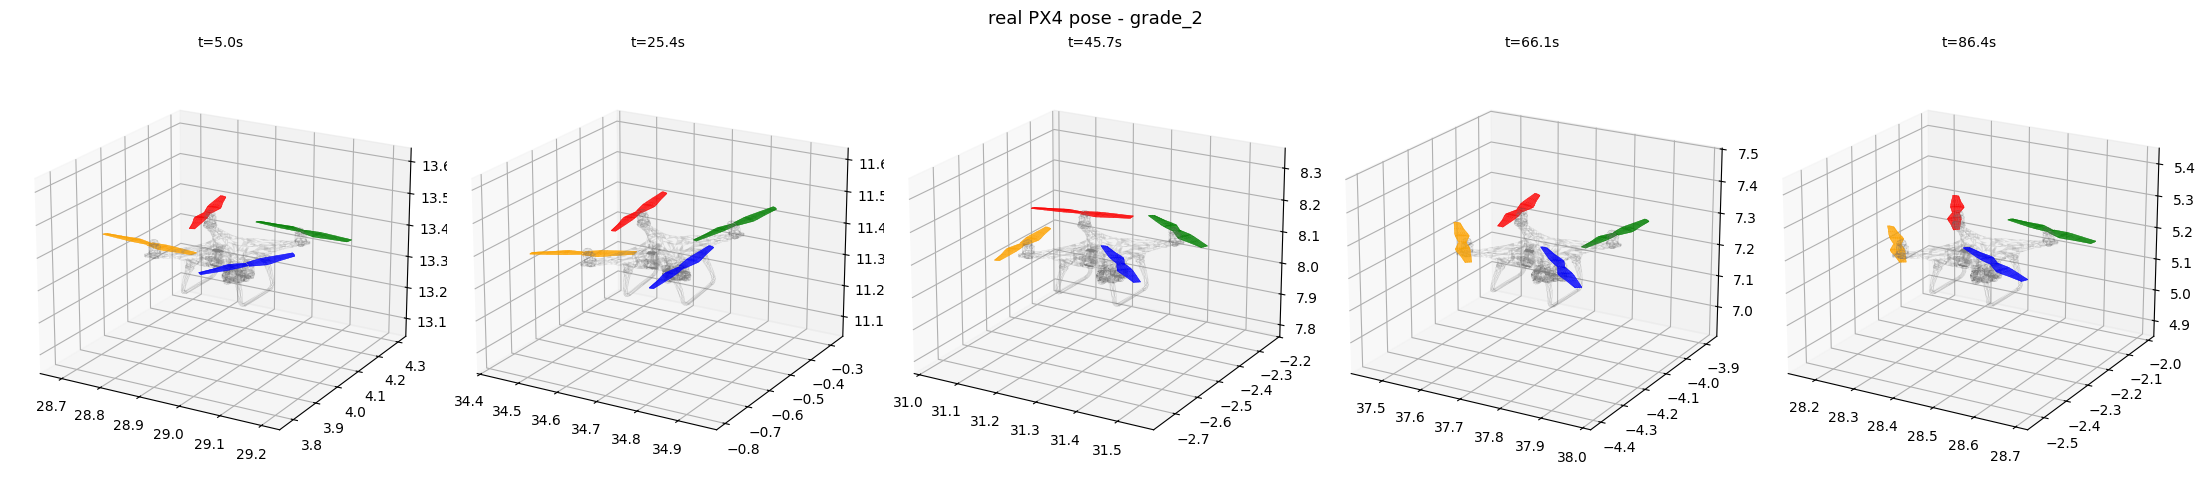

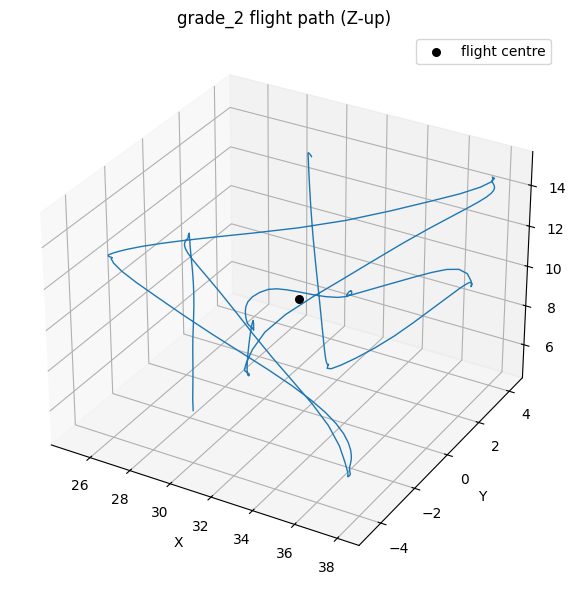

In [6]:
starts = kinematics.window_starts(flight, cfg)
ts = np.linspace(starts[0], starts[-1], 5)
fig = plt.figure(figsize=(22, 5))
for i, t in enumerate(ts):
    ax = fig.add_subplot(1, 5, i+1, projection="3d")
    p = flight.pos_interp(t); R = flight.rot_interp(t).as_matrix(); a = flight.blade_angles_interp(t)
    add_body(ax, R, p, step=3, alpha=0.2); add_blades(ax, R, p, a, alpha=0.5)
    r = 0.3
    ax.set_xlim(p[0]-r, p[0]+r); ax.set_ylim(p[1]-r, p[1]+r); ax.set_zlim(p[2]-r, p[2]+r)
    ax.set_title("t=%.1fs" % t, fontsize=10); ax.view_init(elev=20, azim=-60)
plt.suptitle("real PX4 pose - grade_2", fontsize=13); plt.tight_layout(); plt.show()

tt = np.linspace(cfg.t_skip, flight.t_max, 400); pp = flight.pos_interp(tt)
fig = plt.figure(figsize=(7, 6)); ax = fig.add_subplot(111, projection="3d")
ax.plot(pp[:, 0], pp[:, 1], pp[:, 2], lw=1)
ax.scatter(*flight.flight_center, c="k", s=30, label="flight centre")
ax.set_title("grade_2 flight path (Z-up)"); ax.legend()
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.tight_layout(); plt.show()